<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 16px; text-align:center; border: 1px solid #e94560; margin-bottom: 10px;'>
<h1 style='color:#e94560; font-size:2.6em; font-family:Georgia,serif; margin:0; letter-spacing:2px;'>📚 SkillBoost Analytics</h1>
<h2 style='color:#a8dadc; font-size:1.3em; font-family:Georgia,serif; margin:8px 0 0 0; font-weight:normal;'>Academic & Training Performance Prediction System</h2>
<hr style='border:1px solid #e94560; margin: 18px auto; width:60%;'/>
<p style='color:#ccc; font-size:0.95em; font-style:italic; margin:0;'>A mini project exploring how academics + skill training together predict student outcomes</p>
<p style='color:#888; font-size:0.82em; margin:6px 0 0 0;'>Made by a final-year CSE student &nbsp;|&nbsp; Tools: Python · Pandas · Scikit-learn · Matplotlib · Seaborn</p>
</div>

## 💡 What is this project?

So basically, I wanted to figure out — *can we actually predict how well a student will perform just by looking at their attendance, marks, assignments AND whether they attended any training programs?*

Spoiler: **yes, we can** — and the results are actually pretty interesting.

### What I built:
- 🔍 Data cleaning & exploratory analysis on real student records
- 📊 Visualisations to understand patterns (attendance, marks, training impact)
- 🤖 A machine learning model (Random Forest) that predicts performance labels
- 💬 Personalised, descriptive student remarks with actionable feedback

> *Note: Data is anonymised. All Student IDs are coded (S0001, S0002 …)*

## 📦 Step 1 — Import Libraries

In [1]:
# Core libraries — the usual suspects 😄
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

# Make plots look clean & dark-themed
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'axes.titlecolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Colour palette — one for each performance label
COLORS = {
    'excellent': '#3fb950',
    'good':      '#58a6ff',
    'average':   '#d29922',
    'at-risk':   '#f85149',
    'poor':      '#da3633',
}

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 📂 Step 2 — Load & Merge the Data

I had two separate CSV files:
- `students_clean.csv` — academic records (attendance, marks, assignments, etc.)
- `training.csv` — training program records (scores, attendance, improvement, etc.)

These needed to be merged on `Student_ID` since not every student attended a training.

In [2]:
students = pd.read_csv('students_clean.csv')
training = pd.read_csv('training.csv')

# Merge on Student_ID — left join so we keep all students
df = pd.merge(students, training, on='Student_ID', how='left')

# Fill NaN for students who didn't attend any training
df['Training_Attendance']  = df['Training_Attendance'].fillna('no')
df['Training_Score']       = df['Training_Score'].fillna(0)
df['Feedback_Rating']      = df['Feedback_Rating'].fillna(0)
df['Pre_Training_Score']   = df['Pre_Training_Score'].fillna(0)
df['Post_Training_Score']  = df['Post_Training_Score'].fillna(0)
df['Training_Impact']      = df['Training_Impact'].fillna('no')
df['Improvement']          = df['Improvement'].fillna(0)

# Normalise text columns to lowercase
cat_cols = ['Activity_Participation','Training_Attendance','Training_Impact','Performance_Label']
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

print(f'Dataset shape: {df.shape}')
print(f'\nPerformance Label Counts:')
print(df['Performance_Label'].value_counts())
df.head()

Dataset shape: (2025, 18)

Performance Label Counts:
Performance_Label
good       861
at-risk    602
average    562
Name: count, dtype: int64


,Student_ID,Attendance_Percentage,Mid_Term_Marks,Assignment_Score,Class_Participation,Activity_Participation,Aggregate_Academic_Score,Performance_Label,Training_ID,Course_Name,Training_Type,Training_Attendance,Training_Score,Feedback_Rating,Pre_Training_Score,Post_Training_Score,Training_Impact,Improvement
0,S0001,90.0,80.0,95.0,5.0,no,81.0,good,T00001,Leadership,Soft Skills,no,80.0,3.0,80.0,32.0,no,-48.0
1,S0010,90.0,80.0,95.0,3.0,yes,61.0,at-risk,T00010,Web Development,Technical,yes,80.0,5.0,80.0,80.0,no,0.0
2,S0011,80.0,85.0,95.0,10.0,no,61.0,at-risk,T00011,Cloud Computing,Technical,yes,80.0,3.0,73.0,80.0,no,7.0
3,S0012,90.0,80.0,95.0,8.0,yes,41.0,good,T00012,IoT Basics,Technical,no,57.0,3.0,89.0,80.0,no,-9.0
4,S0013,90.0,78.0,95.0,3.0,yes,39.0,good,T00013,no,Technical,yes,80.0,3.0,80.0,80.0,improvement,0.0


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

Before jumping into ML, I always explore the data first. You'd be surprised what patterns show up just by plotting things!

Let's start with the big picture — **how are students distributed across performance labels?**

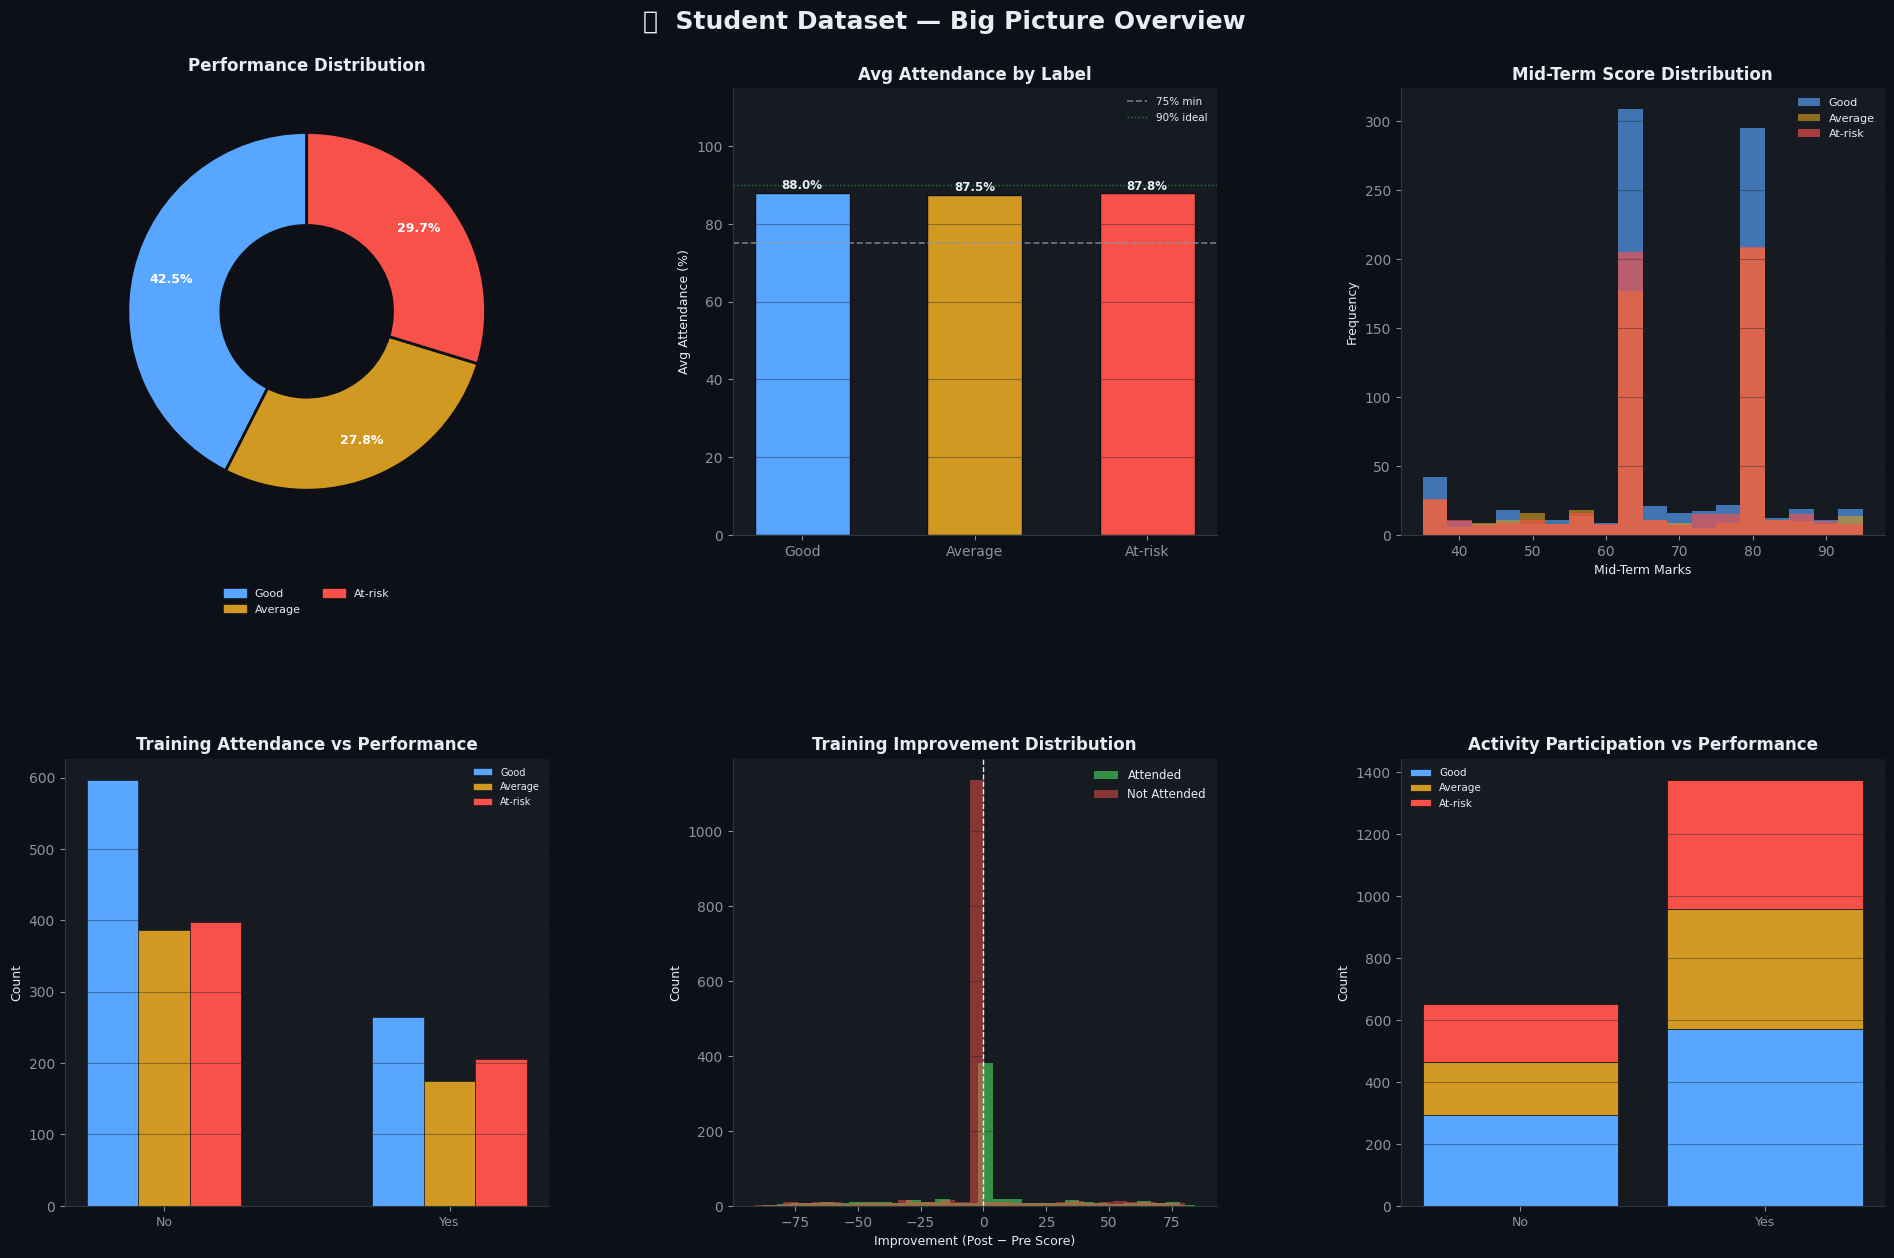


📌 Key Observation: Good students dominate, but At-Risk is the second largest group — needs attention!


In [3]:
order = [l for l in ['excellent','good','average','at-risk','poor']
         if l in df['Performance_Label'].unique()]

fig = plt.figure(figsize=(20, 13), facecolor='#0d1117')
fig.suptitle('📊  Student Dataset — Big Picture Overview',
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38,
                       top=0.92, bottom=0.06, left=0.06, right=0.97)

# ── Donut — Performance distribution ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
perf = df.groupby('Performance_Label')['Student_ID'].nunique().reindex(order)
cols = [COLORS[l] for l in perf.index]
wedges, _, autos = ax1.pie(
    perf.values, colors=cols, autopct='%1.1f%%', startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.52, edgecolor='#0d1117', linewidth=2))
for at in autos: at.set_color('white'); at.set_fontsize(9); at.set_fontweight('bold')
patches = [mpatches.Patch(color=c, label=l.capitalize())
           for l,c in zip(perf.index, cols)]
ax1.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5,-0.2),
           ncol=2, fontsize=8, framealpha=0)
ax1.set_title('Performance Distribution', fontsize=12, fontweight='bold', pad=12)

# ── Bar — Avg attendance by label ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
att = df.groupby('Performance_Label')['Attendance_Percentage'].mean().reindex(order)
bars = ax2.bar([l.capitalize() for l in att.index], att.values,
               color=cols, edgecolor='#0d1117', width=0.55)
ax2.set_ylim(0, 115)
ax2.axhline(75, color='#8b949e', linestyle='--', linewidth=1.2, alpha=0.8, label='75% min')
ax2.axhline(90, color='#3fb950', linestyle=':', linewidth=1, alpha=0.6, label='90% ideal')
ax2.legend(fontsize=7.5, framealpha=0)
ax2.set_ylabel('Avg Attendance (%)', fontsize=9)
ax2.set_title('Avg Attendance by Label', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.4)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f"{b.get_height():.1f}%", ha='center', fontsize=8.5,
             color='#e6edf3', fontweight='bold')

# ── Hist — Mid-term score distribution ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for lbl in order:
    ax3.hist(df[df['Performance_Label']==lbl]['Mid_Term_Marks'],
             bins=18, alpha=0.65, color=COLORS[lbl], label=lbl.capitalize(), edgecolor='none')
ax3.set_xlabel('Mid-Term Marks', fontsize=9)
ax3.set_ylabel('Frequency', fontsize=9)
ax3.set_title('Mid-Term Score Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, framealpha=0); ax3.grid(axis='y', alpha=0.4)

# ── Grouped bar — Training attendance vs performance ──────
ax4 = fig.add_subplot(gs[1, 0])
ta = df.groupby(['Training_Attendance','Performance_Label']).size().unstack(fill_value=0)
ta = ta.reindex(columns=[c for c in order if c in ta.columns])
x  = np.arange(len(ta.index)); w = 0.18
for i,col in enumerate(ta.columns):
    off = (i - len(ta.columns)/2 + 0.5)*w
    ax4.bar(x+off, ta[col], w, label=col.capitalize(),
            color=COLORS[col], edgecolor='#0d1117', linewidth=0.4)
ax4.set_xticks(x); ax4.set_xticklabels([s.capitalize() for s in ta.index], fontsize=9)
ax4.set_ylabel('Count', fontsize=9)
ax4.set_title('Training Attendance vs Performance', fontsize=12, fontweight='bold')
ax4.legend(fontsize=7, framealpha=0); ax4.grid(axis='y', alpha=0.4)

# ── Histogram — Improvement distribution ──────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df[df['Training_Attendance']=='yes']['Improvement'],
         bins=30, alpha=0.75, color='#3fb950', label='Attended', edgecolor='none')
ax5.hist(df[df['Training_Attendance']=='no']['Improvement'],
         bins=30, alpha=0.5, color='#f85149', label='Not Attended', edgecolor='none')
ax5.axvline(0, color='#e6edf3', linestyle='--', linewidth=1)
ax5.set_xlabel('Improvement (Post − Pre Score)', fontsize=9)
ax5.set_ylabel('Count', fontsize=9)
ax5.set_title('Training Improvement Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8.5, framealpha=0); ax5.grid(axis='y', alpha=0.4)

# ── Stacked bar — Activity participation ──────────────────
ax6 = fig.add_subplot(gs[1, 2])
act = df.groupby(['Activity_Participation','Performance_Label']).size().unstack(fill_value=0)
act = act.reindex(columns=[c for c in order if c in act.columns])
bot = np.zeros(len(act))
for col in act.columns:
    ax6.bar(act.index, act[col], bottom=bot, label=col.capitalize(),
            color=COLORS[col], edgecolor='#0d1117', linewidth=0.5)
    bot += act[col].values
ax6.set_xticklabels([s.capitalize() for s in act.index], fontsize=9)
ax6.set_ylabel('Count', fontsize=9)
ax6.set_title('Activity Participation vs Performance', fontsize=12, fontweight='bold')
ax6.legend(fontsize=7.5, framealpha=0); ax6.grid(axis='y', alpha=0.4)

plt.savefig('chart_01_overview.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n📌 Key Observation: Good students dominate, but At-Risk is the second largest group — needs attention!')

### 🔬 Deeper Dive — Correlations & Score Patterns

Now let's see how the features actually relate to each other. A correlation heatmap is my go-to for this — it shows which features move together.

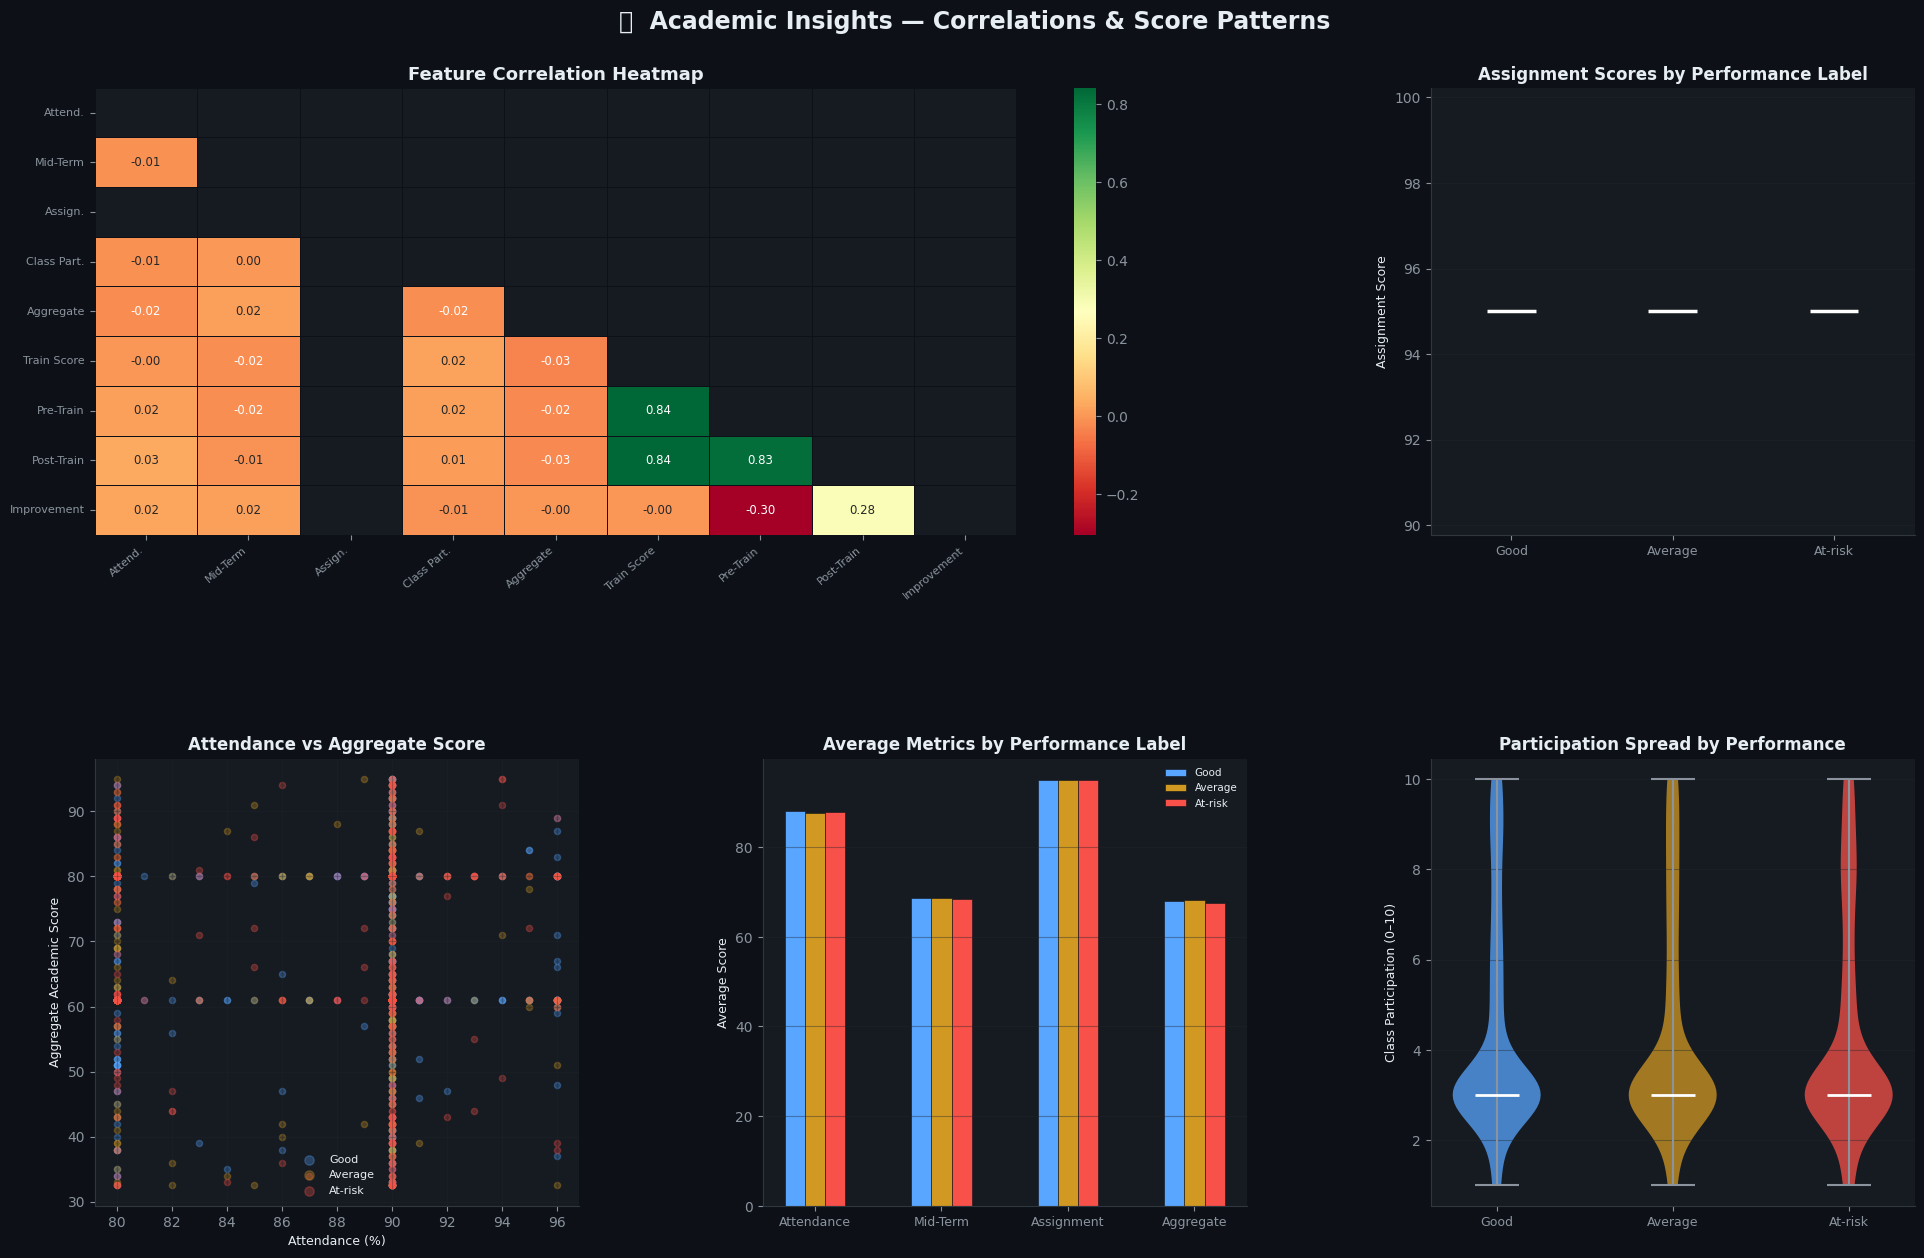


📌 Key Observation: Excellent students have consistently high scores across ALL metrics — no single factor drives it.


In [4]:
fig = plt.figure(figsize=(20, 13), facecolor='#0d1117')
fig.suptitle('📈  Academic Insights — Correlations & Score Patterns',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38,
                       top=0.92, bottom=0.06, left=0.06, right=0.97)

# ── Correlation heatmap ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
num_cols = ['Attendance_Percentage','Mid_Term_Marks','Assignment_Score',
            'Class_Participation','Aggregate_Academic_Score',
            'Training_Score','Pre_Training_Score','Post_Training_Score','Improvement']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax1, linewidths=0.4, linecolor='#0d1117', cbar=True,
            annot_kws={'size': 8.5})
tick_lbs = ['Attend.','Mid-Term','Assign.','Class Part.','Aggregate',
            'Train Score','Pre-Train','Post-Train','Improvement']
ax1.set_xticklabels(tick_lbs, rotation=40, ha='right', fontsize=8)
ax1.set_yticklabels(tick_lbs, rotation=0, fontsize=8)
ax1.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# ── Box plot — assignment score by label ──────────────────
ax2 = fig.add_subplot(gs[0, 2])
data_box = [df[df['Performance_Label']==l]['Assignment_Score'].dropna().values for l in order]
bp = ax2.boxplot(data_box, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(color='#8b949e'), capprops=dict(color='#8b949e'),
                 flierprops=dict(marker='o', markerfacecolor='#8b949e', markersize=3, alpha=0.5))
for patch, lbl in zip(bp['boxes'], order):
    patch.set_facecolor(COLORS[lbl]); patch.set_alpha(0.8)
ax2.set_xticklabels([l.capitalize() for l in order], fontsize=9)
ax2.set_ylabel('Assignment Score', fontsize=9)
ax2.set_title('Assignment Scores by Performance Label', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.4)

# ── Scatter — attendance vs aggregate score ────────────────
ax3 = fig.add_subplot(gs[1, 0])
for lbl in order:
    sub = df[df['Performance_Label']==lbl]
    ax3.scatter(sub['Attendance_Percentage'], sub['Aggregate_Academic_Score'],
               alpha=0.3, s=20, color=COLORS[lbl], label=lbl.capitalize())
ax3.set_xlabel('Attendance (%)', fontsize=9)
ax3.set_ylabel('Aggregate Academic Score', fontsize=9)
ax3.set_title('Attendance vs Aggregate Score', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, framealpha=0, markerscale=1.5)
ax3.grid(alpha=0.3)

# ── Grouped bar — avg metrics by label ────────────────────
ax4 = fig.add_subplot(gs[1, 1])
metrics = ['Attendance_Percentage','Mid_Term_Marks','Assignment_Score','Aggregate_Academic_Score']
m_names  = ['Attendance','Mid-Term','Assignment','Aggregate']
grp = df.groupby('Performance_Label')[metrics].mean().reindex(order)
x = np.arange(len(m_names)); w = 0.16
for i,lbl in enumerate(grp.index):
    off = (i - len(grp)/2 + 0.5)*w
    ax4.bar(x+off, grp.loc[lbl], w, label=lbl.capitalize(),
            color=COLORS[lbl], edgecolor='#0d1117', linewidth=0.4)
ax4.set_xticks(x); ax4.set_xticklabels(m_names, fontsize=9)
ax4.set_ylabel('Average Score', fontsize=9)
ax4.set_title('Average Metrics by Performance Label', fontsize=12, fontweight='bold')
ax4.legend(fontsize=7.5, framealpha=0); ax4.grid(axis='y', alpha=0.4)

# ── Violin — class participation spread ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
parts = [df[df['Performance_Label']==l]['Class_Participation'].dropna().values for l in order]
vp = ax5.violinplot(parts, positions=np.arange(len(order)), showmedians=True)
for pc, lbl in zip(vp['bodies'], order):
    pc.set_facecolor(COLORS[lbl]); pc.set_alpha(0.75)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
for key in ['cbars','cmins','cmaxes']:
    vp[key].set_color('#8b949e')
ax5.set_xticks(np.arange(len(order)))
ax5.set_xticklabels([l.capitalize() for l in order], fontsize=9)
ax5.set_ylabel('Class Participation (0–10)', fontsize=9)
ax5.set_title('Participation Spread by Performance', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.4)

plt.savefig('chart_02_academic_insights.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n📌 Key Observation: Excellent students have consistently high scores across ALL metrics — no single factor drives it.')

### 🏋️ Training Impact — Does it actually help?

This was honestly the most interesting part for me. I expected training to always improve scores, but the data tells a more nuanced story…

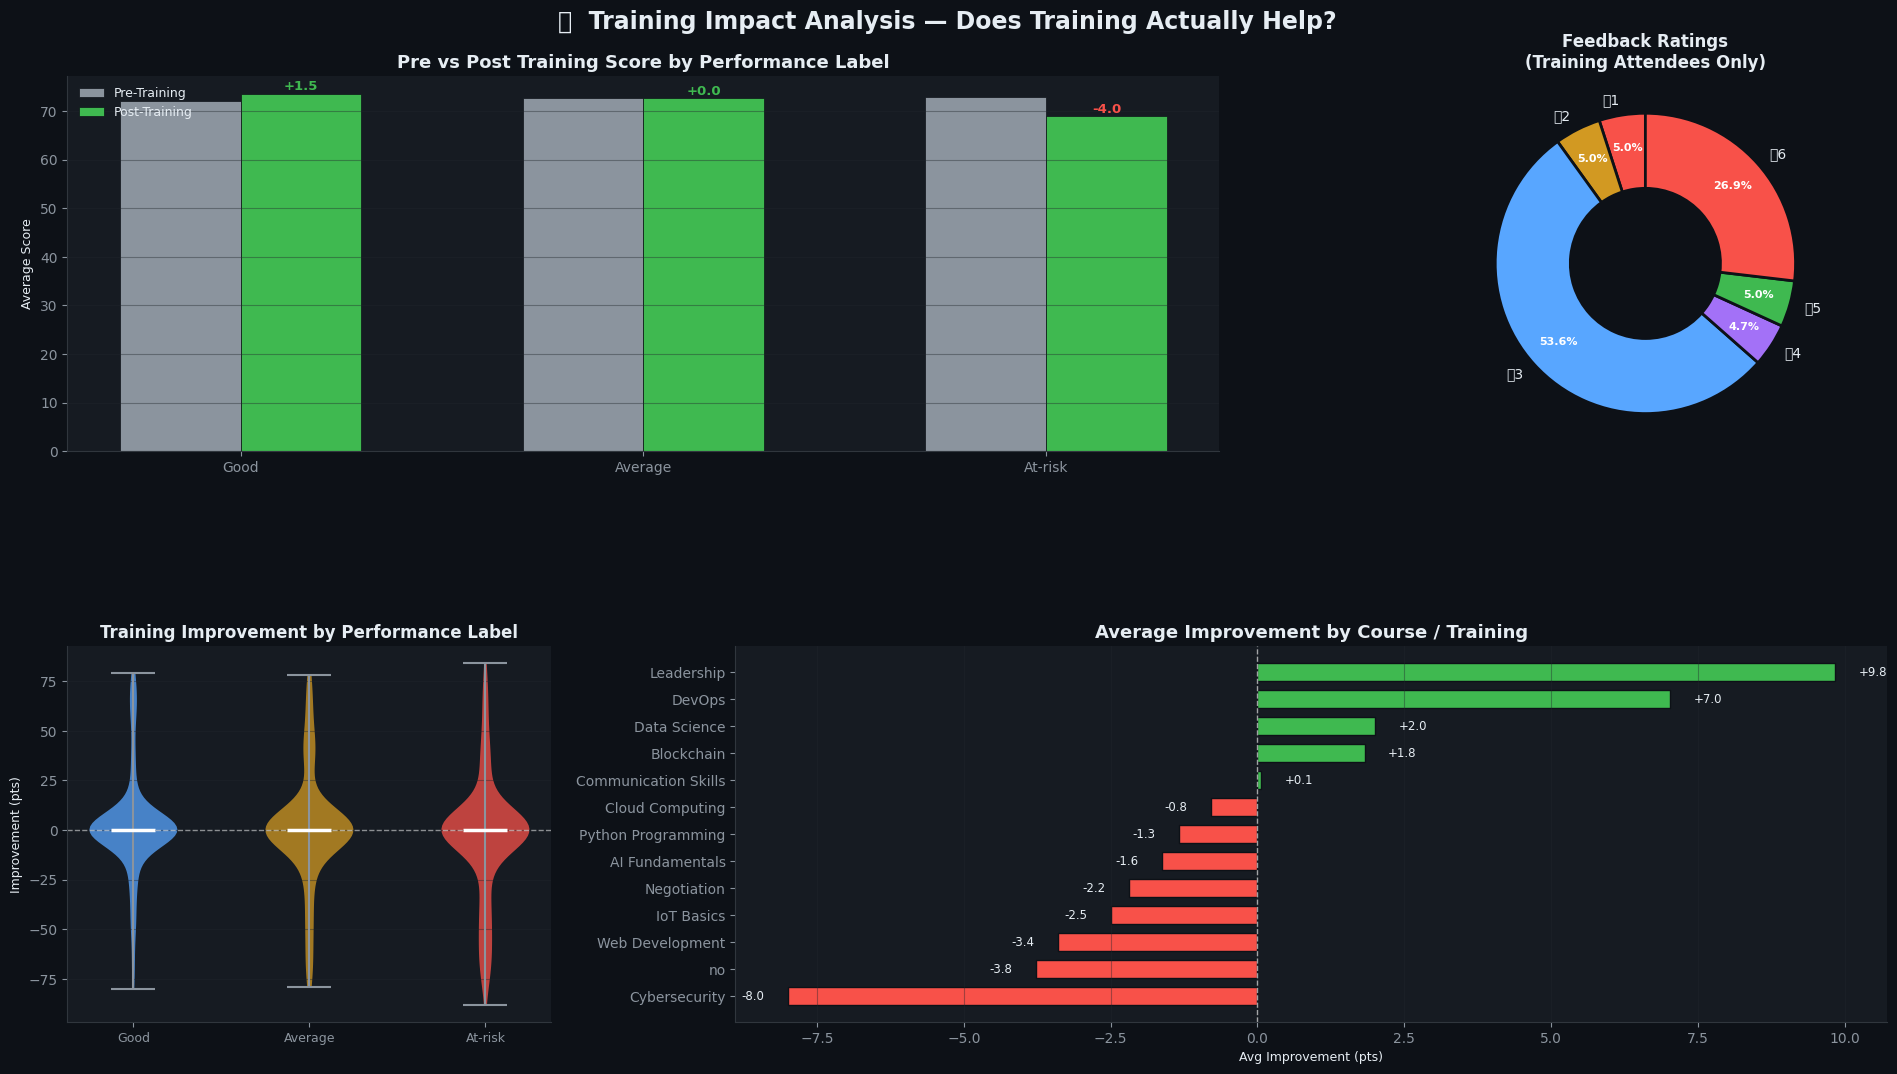


📌 Interesting finding: Not all trainings improve scores — some courses actually show a dip post-training!


In [5]:
fig = plt.figure(figsize=(20, 11), facecolor='#0d1117')
fig.suptitle('🏋️  Training Impact Analysis — Does Training Actually Help?',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38,
                       top=0.92, bottom=0.06, left=0.06, right=0.97)

# ── Pre vs Post by label ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
trained    = df[df['Training_Attendance']=='yes'].groupby('Performance_Label')
pre_m  = trained['Pre_Training_Score'].mean().reindex(order)
post_m = trained['Post_Training_Score'].mean().reindex(order)
x = np.arange(len(order)); w = 0.30
b1 = ax1.bar(x-w/2, pre_m.values,  w, label='Pre-Training',
             color='#8b949e', edgecolor='#0d1117', linewidth=0.5)
b2 = ax1.bar(x+w/2, post_m.values, w, label='Post-Training',
             color='#3fb950', edgecolor='#0d1117', linewidth=0.5)
for xi,(pre,post) in enumerate(zip(pre_m, post_m)):
    diff = post - pre
    col  = '#3fb950' if diff>=0 else '#f85149'
    ax1.annotate(f'{diff:+.1f}', xy=(xi+w/2, post+0.8),
                 ha='center', fontsize=9.5, color=col, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels([l.capitalize() for l in order], fontsize=10)
ax1.set_ylabel('Average Score', fontsize=9)
ax1.set_title('Pre vs Post Training Score by Performance Label', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0); ax1.grid(axis='y', alpha=0.4)

# ── Feedback donut ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
fb = df[df['Training_Attendance']=='yes']['Feedback_Rating'].value_counts().sort_index()
fb_cols = ['#f85149','#d29922','#58a6ff','#a371f7','#3fb950']
wedges, txts, autos = ax2.pie(
    fb.values, labels=[f'⭐{int(k)}' for k in fb.index],
    colors=fb_cols[:len(fb)], autopct='%1.1f%%', startangle=90,
    pctdistance=0.78, wedgeprops=dict(width=0.5, edgecolor='#0d1117', linewidth=2))
for at in autos: at.set_fontsize(8); at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Feedback Ratings\n(Training Attendees Only)', fontsize=12, fontweight='bold')

# ── Violin — improvement by label ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ov   = [l for l in order if len(df[(df['Training_Attendance']=='yes')&(df['Performance_Label']==l)])>1]
impd = [df[(df['Training_Attendance']=='yes')&(df['Performance_Label']==l)]['Improvement'].dropna().values for l in ov]
vp = ax3.violinplot(impd, positions=np.arange(len(ov)), showmedians=True)
for pc,lbl in zip(vp['bodies'],ov):
    pc.set_facecolor(COLORS[lbl]); pc.set_alpha(0.75)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
for key in ['cbars','cmins','cmaxes']: vp[key].set_color('#8b949e')
ax3.axhline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xticks(np.arange(len(ov)))
ax3.set_xticklabels([l.capitalize() for l in ov], fontsize=9)
ax3.set_ylabel('Improvement (pts)', fontsize=9)
ax3.set_title('Training Improvement by Performance Label', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.4)

# ── Course-wise improvement ────────────────────────────────
if 'Course_Name' in df.columns:
    ax4 = fig.add_subplot(gs[1, 1:])
    ci = df[df['Training_Attendance']=='yes'].groupby('Course_Name')['Improvement'].mean().sort_values()
    cc = ['#3fb950' if v>=0 else '#f85149' for v in ci.values]
    brs = ax4.barh(ci.index, ci.values, color=cc, edgecolor='#0d1117', height=0.65)
    ax4.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.6)
    ax4.set_xlabel('Avg Improvement (pts)', fontsize=9)
    ax4.set_title('Average Improvement by Course / Training', fontsize=13, fontweight='bold')
    ax4.grid(axis='x', alpha=0.4)
    for bar in brs:
        v = bar.get_width()
        ax4.text(v+(0.4 if v>=0 else -0.4), bar.get_y()+bar.get_height()/2,
                 f'{v:+.1f}', va='center', ha='left' if v>=0 else 'right',
                 fontsize=8.5, color='#e6edf3')

plt.savefig('chart_03_training_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('\n📌 Interesting finding: Not all trainings improve scores — some courses actually show a dip post-training!')

## 🤖 Step 4 — Machine Learning Model

Alright, the fun part! I compared three classifiers:
- **Random Forest** — my go-to for tabular data, handles non-linearity well
- **Gradient Boosting** — usually strong on imbalanced classes
- **Logistic Regression** — simple baseline to beat

I used **stratified train-test split (80/20)** + **5-fold cross-validation** to make sure results are reliable.

In [6]:
# ── Encode categorical features ────────────────────────────
encoders = {}
for c in ['Activity_Participation','Training_Attendance','Training_Impact','Performance_Label']:
    le = LabelEncoder()
    df[c+'_enc'] = le.fit_transform(df[c])
    encoders[c] = le

FEATURES = [
    'Attendance_Percentage','Mid_Term_Marks','Assignment_Score',
    'Class_Participation','Activity_Participation_enc',
    'Aggregate_Academic_Score','Training_Attendance_enc',
    'Training_Score','Feedback_Rating',
    'Pre_Training_Score','Post_Training_Score','Improvement',
]

X = df[FEATURES]
y = df['Performance_Label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Train all three models ──────────────────────────────────
models = {
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

results = {}
print('Model Training Results:')
print('-'*60)
for name, mdl in models.items():
    mdl.fit(X_train_sc, y_train)
    yp   = mdl.predict(X_test_sc)
    acc  = accuracy_score(y_test, yp)
    f1   = f1_score(y_test, yp, average='weighted')
    cv   = cross_val_score(mdl, scaler.transform(X), y,
                           cv=StratifiedKFold(5), scoring='accuracy').mean()
    results[name] = {'model':mdl,'acc':acc,'f1':f1,'cv':cv,'yp':yp}
    print(f'{name:<25}  Acc={acc:.4f}  F1={f1:.4f}  CV={cv:.4f}')

best_name = max(results, key=lambda k: results[k]['f1'])
best = results[best_name]
print(f'\n🏆 Best Model: {best_name}  (F1 = {best["f1"]:.4f})')

joblib.dump(best['model'], 'student_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(encoders,      'encoders.pkl')
print('💾 Model artefacts saved!')

Model Training Results:
------------------------------------------------------------
Random Forest              Acc=0.3556  F1=0.3435  CV=0.3565
Gradient Boosting          Acc=0.3679  F1=0.3318  CV=0.3827
Logistic Regression        Acc=0.4247  F1=0.2545  CV=0.4168

🏆 Best Model: Random Forest  (F1 = 0.3435)
💾 Model artefacts saved!


### 📊 Model Evaluation — Visualising Performance

Numbers in a table don't really tell the story. Let me visualise the model results properly.

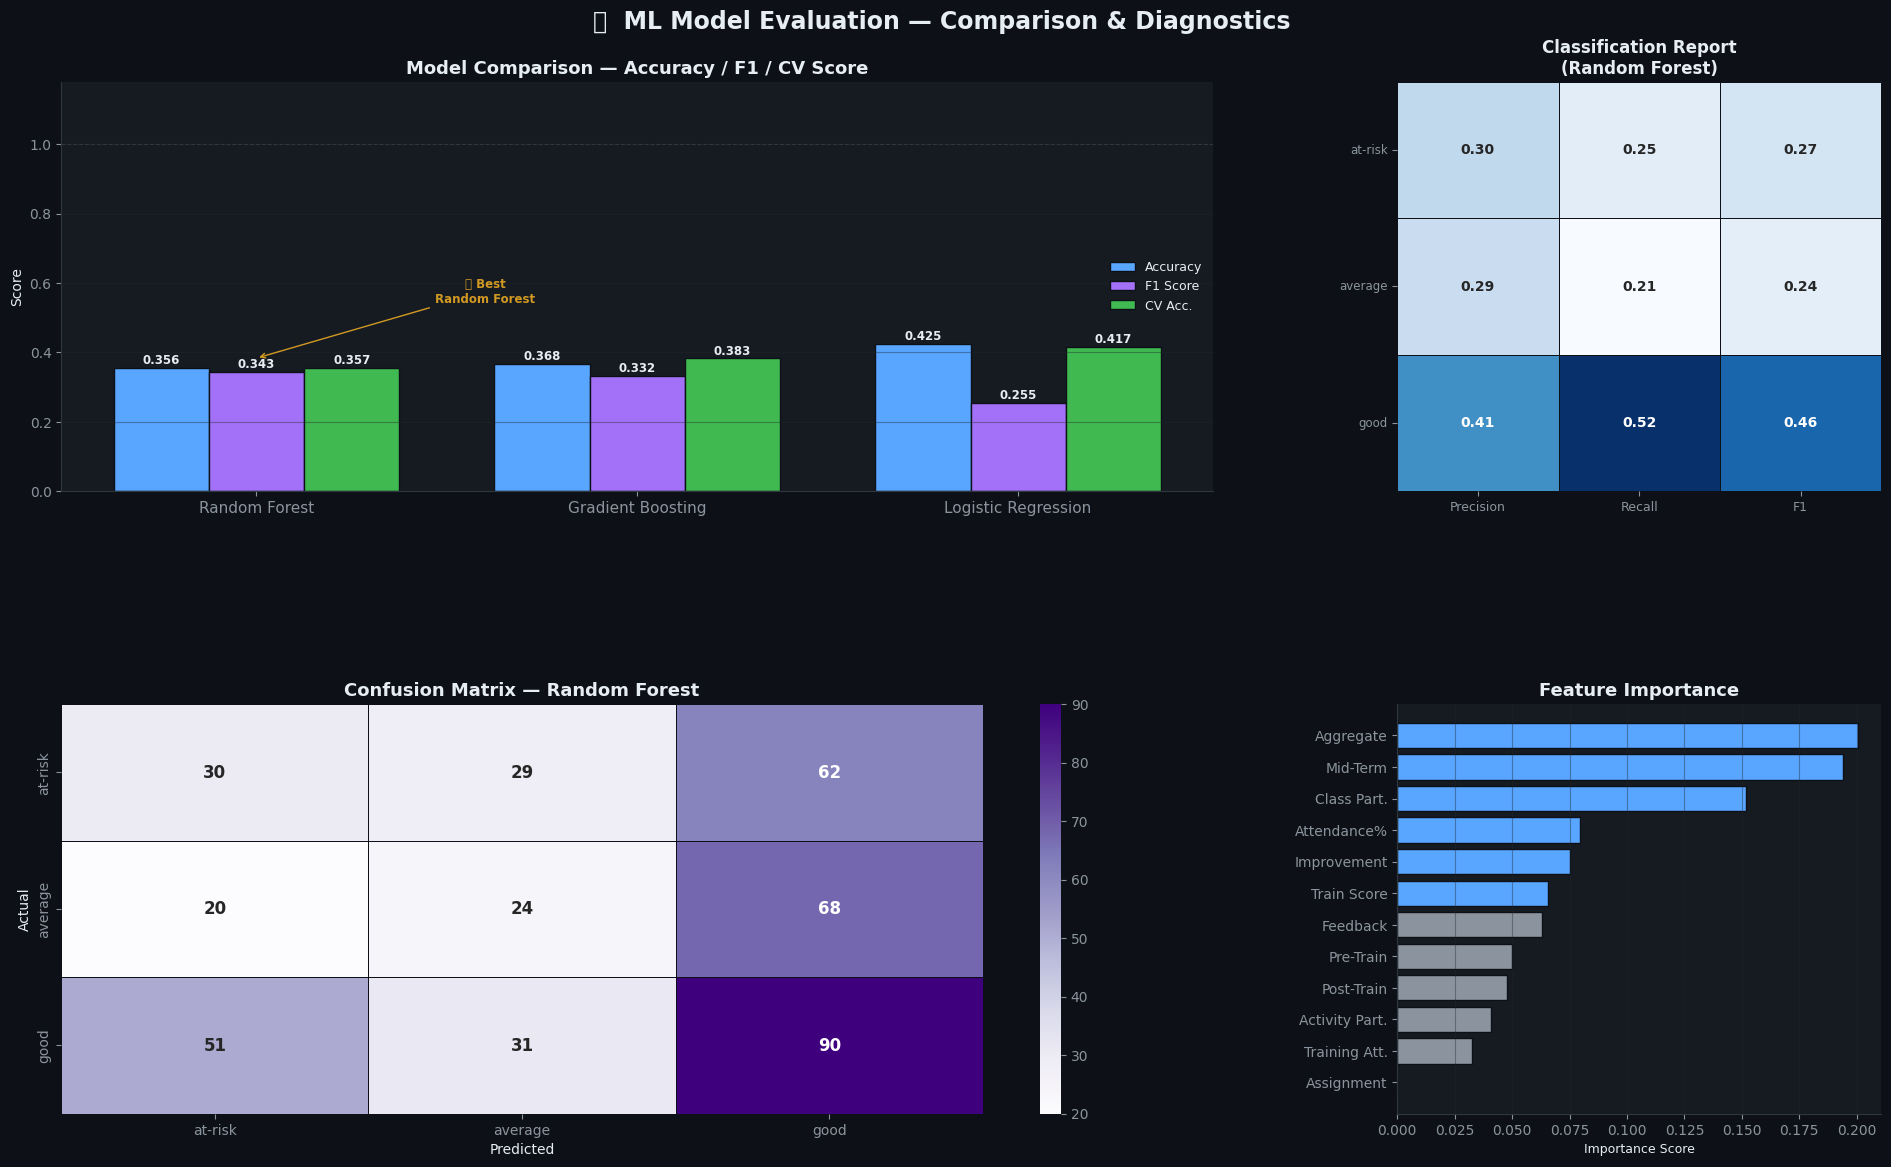

In [7]:
label_names = encoders['Performance_Label'].classes_
model_names = list(results.keys())

fig = plt.figure(figsize=(20, 12), facecolor='#0d1117')
fig.suptitle('🤖  ML Model Evaluation — Comparison & Diagnostics',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38,
                       top=0.92, bottom=0.06, left=0.06, right=0.97)

# ── Model metric comparison bar ────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
accs=[results[n]['acc'] for n in model_names]
f1s =[results[n]['f1']  for n in model_names]
cvs =[results[n]['cv']  for n in model_names]
x=np.arange(len(model_names)); w=0.25
b1=ax1.bar(x-w,accs,w,label='Accuracy',  color='#58a6ff', edgecolor='#0d1117')
b2=ax1.bar(x,  f1s, w,label='F1 Score',  color='#a371f7', edgecolor='#0d1117')
b3=ax1.bar(x+w,cvs, w,label='CV Acc.',   color='#3fb950', edgecolor='#0d1117')
ax1.set_xticks(x); ax1.set_xticklabels(model_names, fontsize=11)
ax1.set_ylim(0, 1.18); ax1.set_ylabel('Score', fontsize=10)
ax1.set_title('Model Comparison — Accuracy / F1 / CV Score', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0); ax1.grid(axis='y', alpha=0.4)
ax1.axhline(1.0, color='#30363d', linestyle='--', linewidth=0.8)
for bars in [b1,b2,b3]:
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8.5,
                 color='#e6edf3', fontweight='bold')
bidx = model_names.index(best_name)
ax1.annotate(f'🏆 Best\n{best_name}',
             xy=(bidx, best['f1']+0.04), fontsize=8.5,
             color='#d29922', ha='center', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#d29922'),
             xytext=(bidx+0.6, best['f1']+0.20))

# ── Classification report heatmap ─────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
from sklearn.metrics import classification_report
cr = classification_report(y_test, best['yp'], target_names=label_names,
                            output_dict=True, zero_division=0)
cr_df = pd.DataFrame(cr).T.iloc[:-3, :3]
sns.heatmap(cr_df, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, linecolor='#0d1117', ax=ax2, cbar=False,
            annot_kws={'size':10,'weight':'bold'})
ax2.set_title(f'Classification Report\n({best_name})', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['Precision','Recall','F1'], fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=8.5, rotation=0)

# ── Confusion matrix ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
cm = confusion_matrix(y_test, best['yp'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.4, linecolor='#0d1117', ax=ax3, cbar=True,
            annot_kws={'size':12,'weight':'bold'})
ax3.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=10); ax3.set_ylabel('Actual', fontsize=10)

# ── Feature importance ─────────────────────────────────────
if hasattr(best['model'], 'feature_importances_'):
    ax4 = fig.add_subplot(gs[1, 2])
    flbls = ['Attendance%','Mid-Term','Assignment','Class Part.',
             'Activity Part.','Aggregate','Training Att.',
             'Train Score','Feedback','Pre-Train','Post-Train','Improvement']
    imp = best['model'].feature_importances_
    sidx = np.argsort(imp)
    fc = ['#58a6ff' if imp[i]>=np.median(imp) else '#8b949e' for i in sidx]
    ax4.barh([flbls[i] for i in sidx], imp[sidx], color=fc, edgecolor='#0d1117')
    ax4.set_title('Feature Importance', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Importance Score', fontsize=9)
    ax4.grid(axis='x', alpha=0.4)

plt.savefig('chart_04_model_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 💬 Step 5 — Student Prediction & Personalised Remarks

This is honestly the part I'm most proud of. Instead of just spitting out a label like 'Good' or 'At-Risk', I wanted the system to give **real, descriptive feedback** — the kind a teacher would write.

Every remark is generated based on the actual values of that specific student. The idea is: if a student scores low in assignments but has good attendance, the system should acknowledge the effort while pointing out what needs work.

In [8]:
def predict_student(data_dict):
    """
    Takes a dict of student features, returns:
    - predicted label
    - class probabilities
    - list of (icon, heading, detail, color) remarks
    - action plan string
    """
    row = {}
    for col in FEATURES:
        raw = col.replace('_enc','')
        if col.endswith('_enc'):
            val = str(data_dict.get(raw,'no')).strip().lower()
            le  = encoders[raw]
            row[col] = int(le.transform([val])[0]) if val in le.classes_ else 0
        else:
            row[col] = float(data_dict[col])

    Xs  = pd.DataFrame([row], columns=FEATURES)
    Xsc = scaler.transform(Xs)
    pn  = best['model'].predict(Xsc)[0]
    plb = encoders['Performance_Label'].inverse_transform([pn])[0]
    proba = best['model'].predict_proba(Xsc)[0]
    pd_   = {encoders['Performance_Label'].classes_[i]: round(float(p),4)
             for i,p in enumerate(proba)}

    # ── Generate remarks ───────────────────────────────────
    remarks = []
    att  = float(data_dict.get('Attendance_Percentage', 0))
    mid  = float(data_dict.get('Mid_Term_Marks', 0))
    asgn = float(data_dict.get('Assignment_Score', 0))
    part = float(data_dict.get('Class_Participation', 0))
    imp  = float(data_dict.get('Improvement', 0))
    agg  = float(data_dict.get('Aggregate_Academic_Score', 0))
    ta   = str(data_dict.get('Training_Attendance','no')).lower()
    ts   = float(data_dict.get('Training_Score', 0))
    fb   = float(data_dict.get('Feedback_Rating', 0))
    pre  = float(data_dict.get('Pre_Training_Score', 0))
    post = float(data_dict.get('Post_Training_Score', 0))

    # Attendance
    if att >= 90:
        remarks.append(('✅','Outstanding Attendance',
            f'With {att:.0f}% attendance, this student is setting the benchmark. '
            f'Consistent presence shows real commitment and correlates strongly with high performance.',
            '#3fb950'))
    elif att >= 75:
        remarks.append(('⚠️','Attendance Needs a Push',
            f'At {att:.0f}%, attendance meets the minimum requirement — but just barely. '
            f'Research shows every 5% increase in attendance can improve final scores by ~3 marks. '
            f'Try to target 90%+ consistently.',
            '#d29922'))
    else:
        remarks.append(('❌','Critical Attendance Issue',
            f'Only {att:.0f}% attendance is a serious concern. Missing classes means missing concepts, '
            f'examples, and Q&A sessions that cannot be replaced by notes alone. '
            f'This MUST be addressed before any other improvement is possible.',
            '#f85149'))

    # Mid-term
    if mid >= 85:
        remarks.append(('✅','Excellent Mid-Term Performance',
            f'{mid:.0f}/100 in mid-terms demonstrates deep subject understanding. '
            f'Keep this momentum going and use this strong foundation to ace end-semester exams.',
            '#3fb950'))
    elif mid >= 70:
        remarks.append(('✅','Good Mid-Term Score',
            f'Scoring {mid:.0f}/100 is above average — solid work. '
            f'Identify which topics cost marks and spend 30 mins/day on targeted revision.',
            '#58a6ff'))
    elif mid >= 55:
        remarks.append(('⚠️','Average Mid-Term — Improvement Possible',
            f'A score of {mid:.0f}/100 is neither comfortable nor alarming. '
            f'The end-semester counts more — start revision early, focus on weak chapters, '
            f'and attempt previous year papers to build exam confidence.',
            '#d29922'))
    else:
        remarks.append(('❌','Mid-Term Marks Are a Red Flag',
            f'{mid:.0f}/100 suggests significant gaps in understanding. '
            f'Do not wait — meet your subject teacher, join a study group, '
            f'and focus on core concepts before the end-semester.',
            '#f85149'))

    # Assignments
    if asgn >= 85:
        remarks.append(('✅','Exceptional Assignment Work',
            f'An assignment score of {asgn:.0f}/100 shows that this student takes submissions seriously. '
            f'The habit of consistent, quality work is one of the strongest predictors of long-term success.',
            '#3fb950'))
    elif asgn >= 65:
        remarks.append(('⚠️','Assignments Are Decent — Can Do Better',
            f'{asgn:.0f}/100 for assignments is average. '
            f'Read instructor feedback carefully and implement suggestions. '
            f'Every 5 marks here can shift your final grade significantly.',
            '#d29922'))
    else:
        remarks.append(('❌','Assignment Performance Is Poor',
            f'Only {asgn:.0f}/100 for assignments raises concerns about consistency and effort. '
            f'Assignments are low-pressure, high-value tasks — start submitting on time '
            f'and treat each one as practice for the final exam.',
            '#f85149'))

    # Participation
    if part >= 8:
        remarks.append(('✅','Highly Engaged Learner',
            f'Class participation of {part:.0f}/10 — this student is asking questions, '
            f'contributing discussions, and actively building understanding in real-time. '
            f'This kind of engagement leads to natural concept retention.',
            '#3fb950'))
    elif part >= 5:
        remarks.append(('⚠️','Moderate Participation',
            f'Rated {part:.0f}/10 for class participation. You are engaging, but there is room to push more. '
            f'Try to ask at least one question per class — it forces you to process information actively.',
            '#d29922'))
    else:
        remarks.append(('❌','Low Classroom Engagement',
            f'Only {part:.0f}/10 for participation suggests a passive learning style. '
            f'Passive learners retain roughly 20% less than active ones. '
            f'Start small — even one answer or question per session makes a measurable difference.',
            '#f85149'))

    # Aggregate
    if agg >= 80:
        remarks.append(('🌟','Strong Overall Academic Score',
            f'An aggregate of {agg:.0f}/100 places this student comfortably in the top tier. '
            f'The consistency across all metrics is commendable.',
            '#3fb950'))
    elif agg >= 60:
        remarks.append(('📊','Average Aggregate Score',
            f'An aggregate of {agg:.0f}/100 shows a mixed academic profile. '
            f'Some areas are strong, others drag the score down. '
            f'Focus on the weakest metric first for maximum improvement.',
            '#d29922'))
    else:
        remarks.append(('📉','Aggregate Score Needs Urgent Attention',
            f'With an aggregate of only {agg:.0f}/100, this student is at risk academically. '
            f'A structured improvement plan covering all subjects is needed immediately.',
            '#f85149'))

    # Training
    if ta == 'yes':
        if imp > 15:
            remarks.append(('🚀','Exceptional Training Impact',
                f'An improvement of {imp:+.1f} points after training is outstanding! '
                f'This shows strong ability to apply new skills practically. '
                f'Continue pursuing advanced training programs.',
                '#58a6ff'))
        elif imp > 5:
            remarks.append(('📈','Good Training Improvement',
                f'Training resulted in a {imp:+.1f} point improvement — a solid return on investment. '
                f'Consider enrolling in follow-up or advanced courses to build further.',
                '#a371f7'))
        elif imp > 0:
            remarks.append(('📈','Marginal Training Improvement',
                f'Scored {imp:+.1f} higher post-training. Improvement is there but modest. '
                f'Apply the learned skills actively in assignments and projects for better retention.',
                '#d29922'))
        elif imp == 0:
            remarks.append(('⚪','Training Had Neutral Impact',
                f'No change in score post-training (Δ = 0). This could mean the training was too basic '
                f'or too advanced. Explore a program better matched to current skill level.',
                '#8b949e'))
        else:
            remarks.append(('📉','Post-Training Score Dipped',
                f'Score dropped by {abs(imp):.1f} pts post-training — possibly due to test difficulty '
                f'or skill mismatch. Review what was taught and seek clarification on weak points.',
                '#f85149'))
    else:
        remarks.append(('⚪','No Training Attended',
            'This student has not participated in any training program yet. '
            'Even one relevant workshop can open new perspectives and improve academic application. '
            'Check with your department for upcoming programs.',
            '#8b949e'))

    suggestions = {
        'excellent': '🎯  You are performing at the highest level — consider going beyond the curriculum. '
                     'Participate in hackathons, contribute to open source, mentor juniors, '
                     'or pursue advanced certifications. The sky is the limit.',
        'good':      '🎯  You are doing well, but excellence is within reach. '
                     'Identify your 1–2 weakest areas and give them dedicated weekly time. '
                     'Maintain training participation and push that aggregate above 80.',
        'average':   '🎯  You have potential that is not fully showing in your results yet. '
                     'Create a structured weekly study plan, be consistent, attend all trainings, '
                     'and do not hesitate to ask for help. Consistency beats talent.',
        'at-risk':   '🎯  This is urgent — do not ignore these signals. '
                     'Please speak with your faculty advisor, create a daily study schedule, '
                     'improve attendance immediately, and enrol in at least one support program.',
        'poor':      '🎯  Immediate intervention is required. '
                     'Meet your counsellor and subject teachers today. '
                     'A personalised academic support plan is essential right now.',
    }
    action = suggestions.get(plb.lower(), '🎯  Review all metrics and create a structured improvement plan.')
    return plb, pd_, remarks, action

print('✅ predict_student() function ready!')

✅ predict_student() function ready!


### 🎓 Running a Prediction — Sample Student Dashboard

Let me run the model on a real student from the dataset and generate their full dashboard.
You can swap in any student's values in `SAMPLE_STUDENT` below.

In [9]:
# ── Change these values to predict any student ─────────────
sample = df.iloc[0]
SAMPLE_STUDENT = {
    'Attendance_Percentage':    float(sample['Attendance_Percentage']),
    'Mid_Term_Marks':           float(sample['Mid_Term_Marks']),
    'Assignment_Score':         float(sample['Assignment_Score']),
    'Class_Participation':      float(sample['Class_Participation']),
    'Activity_Participation':   str(sample['Activity_Participation']),
    'Aggregate_Academic_Score': float(sample['Aggregate_Academic_Score']),
    'Training_Attendance':      str(sample['Training_Attendance']),
    'Training_Score':           float(sample['Training_Score']),
    'Feedback_Rating':          float(sample['Feedback_Rating']),
    'Pre_Training_Score':       float(sample['Pre_Training_Score']),
    'Post_Training_Score':      float(sample['Post_Training_Score']),
    'Improvement':              float(sample['Improvement']),
}
STUDENT_NAME = str(sample.get('Student_ID','S0001'))

pred_lb, proba_d, remarks, action = predict_student(SAMPLE_STUDENT)

print(f'Student ID : {STUDENT_NAME}')
print(f'Prediction : {pred_lb.upper()}')
print(f'Probabilities:')
for k,v in sorted(proba_d.items(), key=lambda x:-x[1]):
    print(f'  {k:<12} {v*100:.1f}%')

Student ID : S0001
Prediction : GOOD
Probabilities:
  good         54.3%
  at-risk      28.3%
  average      17.3%


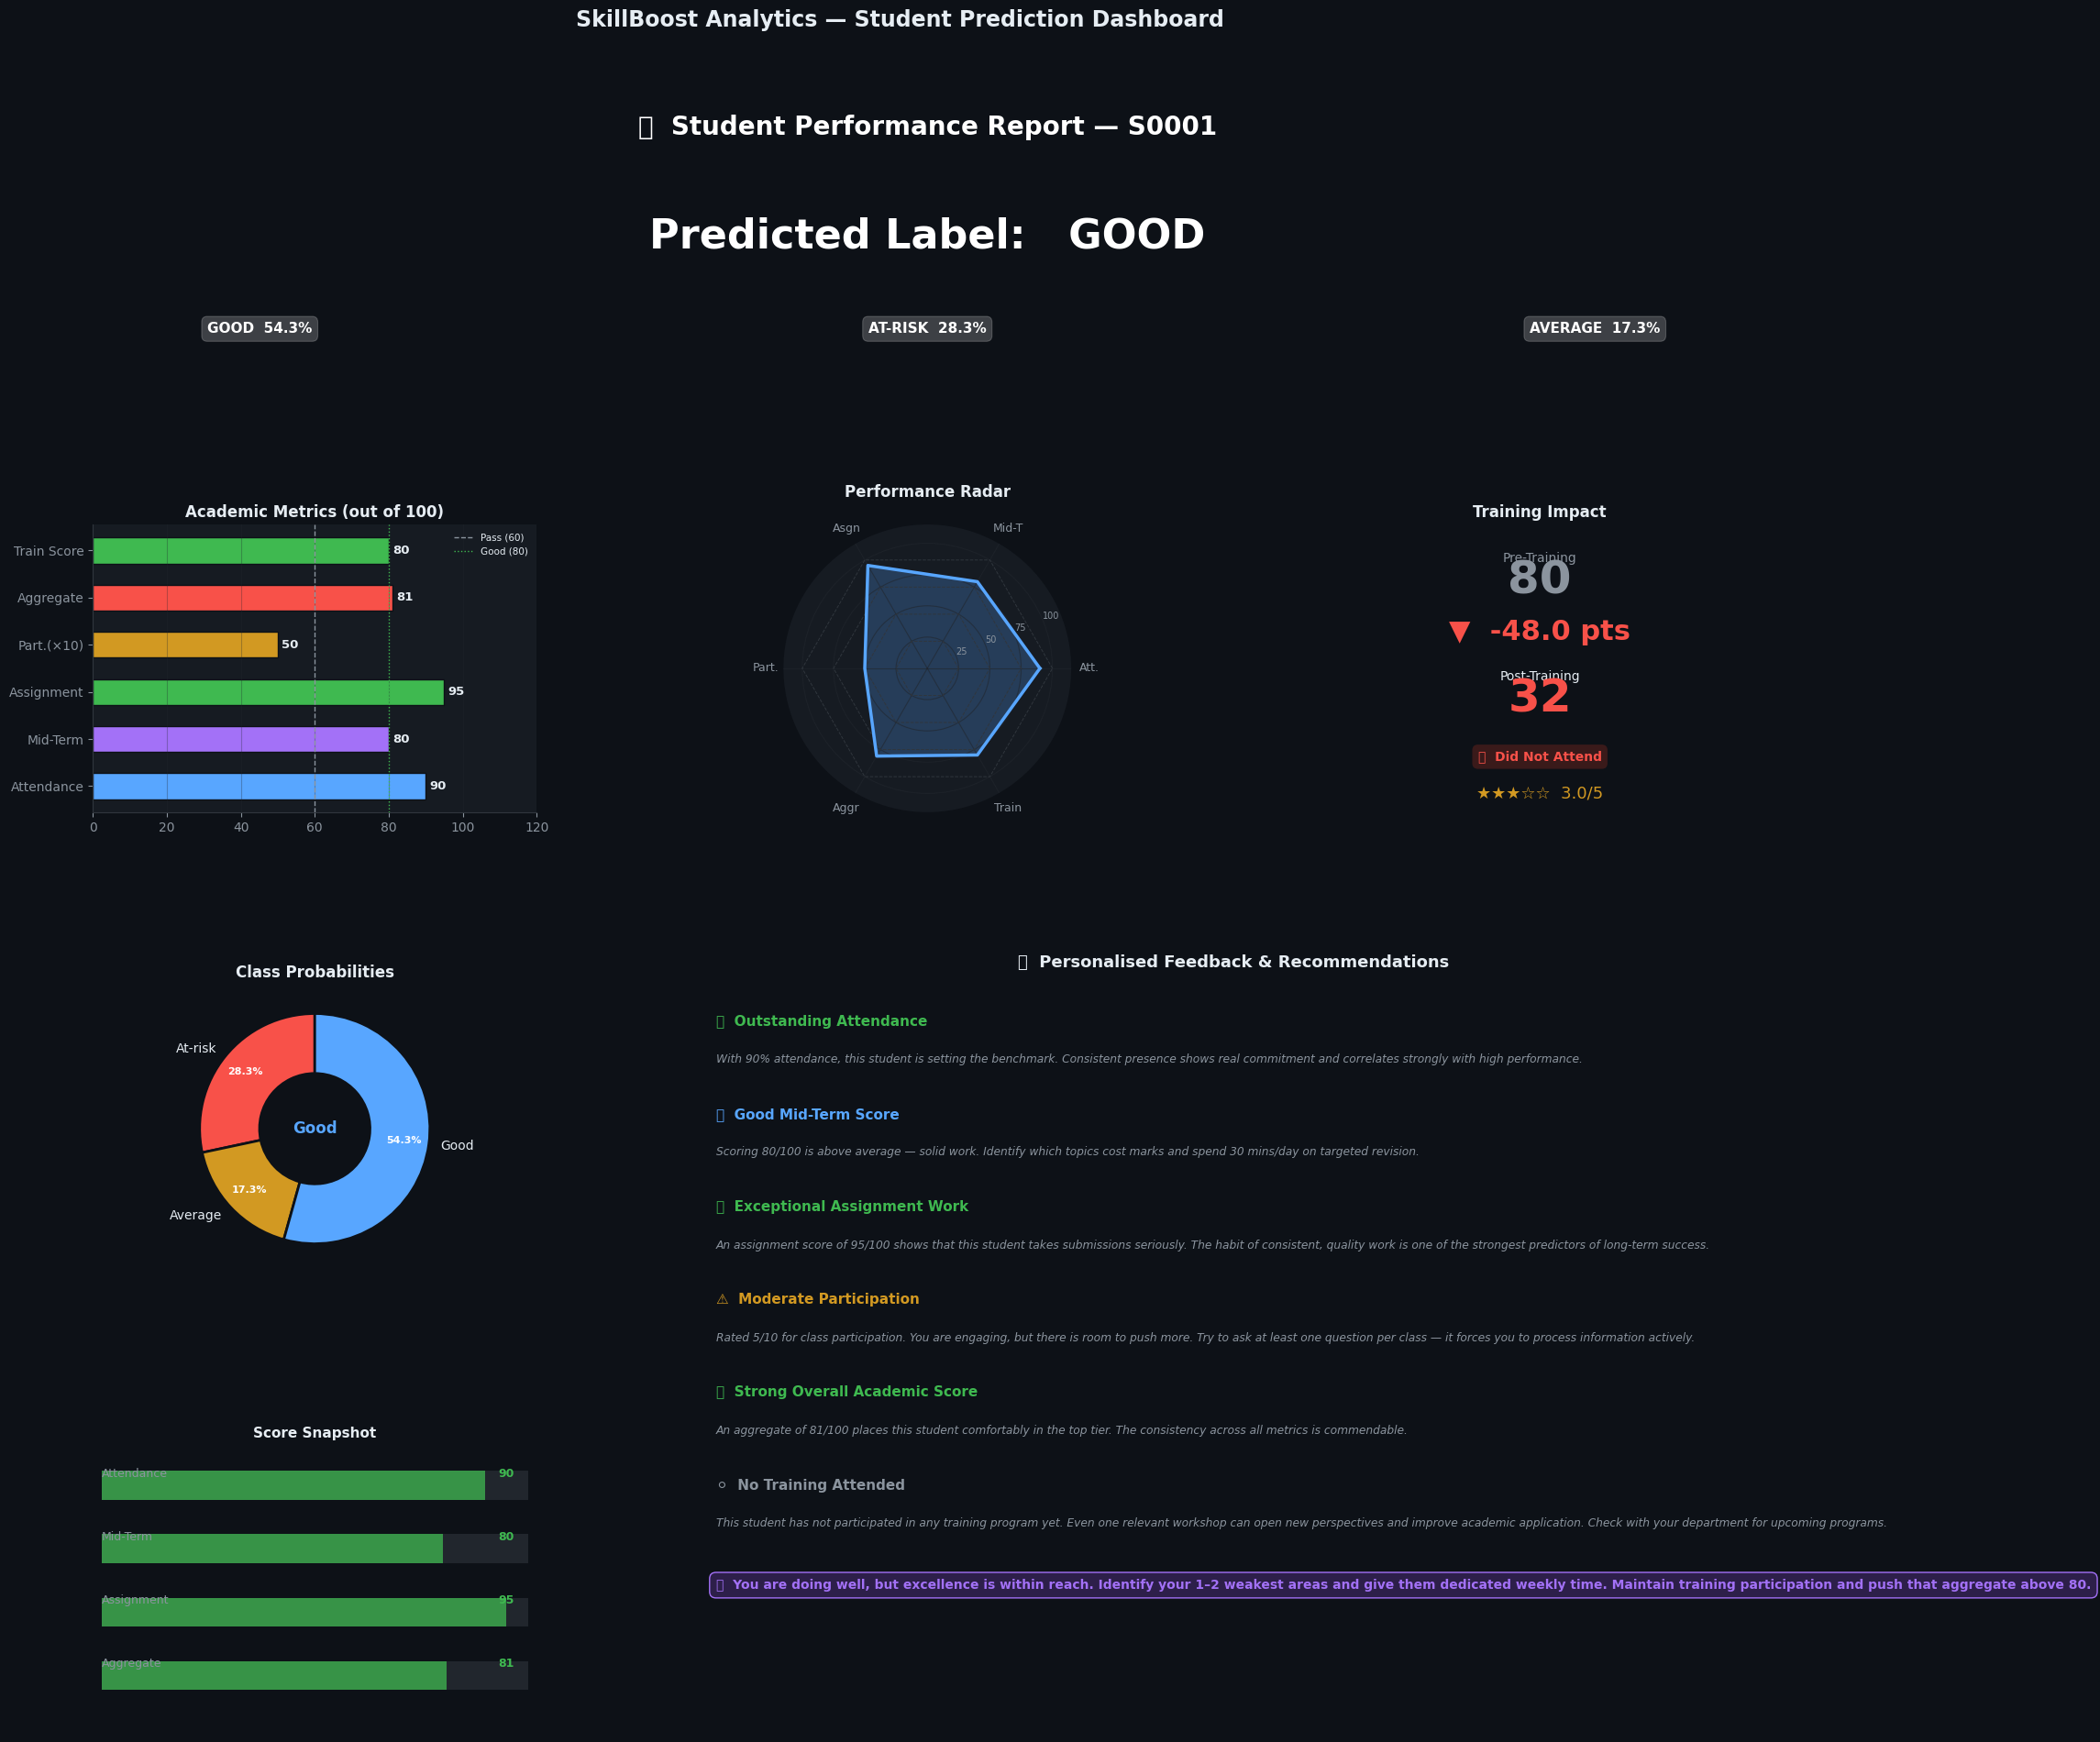

In [10]:
def label_color(lbl):
    return COLORS.get(str(lbl).strip().lower(), '#58a6ff')

accent = label_color(pred_lb)

fig = plt.figure(figsize=(20, 20), facecolor='#0d1117')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.60, wspace=0.38,
                        top=0.94, bottom=0.03, left=0.06, right=0.97)

# ════ BANNER ═════════════════════════════════════════════
ax_b = fig.add_subplot(gs[0, :])
ax_b.set_facecolor(accent); ax_b.axis('off')
ax_b.set_xlim(0,1); ax_b.set_ylim(0,1)
ax_b.text(0.5, 0.78, f'🎓  Student Performance Report — {STUDENT_NAME}',
          ha='center', va='center', fontsize=20, fontweight='bold',
          color='white', transform=ax_b.transAxes)
ax_b.text(0.5, 0.40, f'Predicted Label:   {pred_lb.upper()}',
          ha='center', va='center', fontsize=32, fontweight='bold',
          color='white', transform=ax_b.transAxes)
chip_x = np.linspace(0.10, 0.90, len(proba_d))
for (lbl, p), cx in zip(sorted(proba_d.items(), key=lambda x:-x[1]), chip_x):
    ax_b.text(cx, 0.08, f'{lbl.upper()}  {p*100:.1f}%',
              ha='center', va='center', fontsize=11, color='white', fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                        alpha=0.20, edgecolor='white', linewidth=0.8),
              transform=ax_b.transAxes)

# ════ ACADEMIC METRIC BAR ═══════════════════════════════
ax_ac = fig.add_subplot(gs[1, 0])
ac_labels = ['Attendance','Mid-Term','Assignment','Part.(×10)','Aggregate','Train Score']
ac_values = [
    SAMPLE_STUDENT['Attendance_Percentage'],
    SAMPLE_STUDENT['Mid_Term_Marks'],
    SAMPLE_STUDENT['Assignment_Score'],
    SAMPLE_STUDENT['Class_Participation']*10,
    SAMPLE_STUDENT['Aggregate_Academic_Score'],
    SAMPLE_STUDENT['Training_Score'],
]
bar_colors = ['#58a6ff','#a371f7','#3fb950','#d29922','#f85149','#3fb950']
bars = ax_ac.barh(ac_labels, ac_values, color=bar_colors,
                  edgecolor='#0d1117', height=0.55)
ax_ac.set_xlim(0, 120)
ax_ac.axvline(60, color='#8b949e', linestyle='--', linewidth=1, label='Pass (60)')
ax_ac.axvline(80, color='#3fb950', linestyle=':', linewidth=1, label='Good (80)')
ax_ac.legend(fontsize=7.5, framealpha=0)
ax_ac.set_title('Academic Metrics (out of 100)', fontsize=12, fontweight='bold')
ax_ac.grid(axis='x', alpha=0.3)
for bar in bars:
    ax_ac.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
               f'{bar.get_width():.0f}', va='center', fontsize=9.5,
               color='#e6edf3', fontweight='bold')

# ════ RADAR CHART ════════════════════════════════════════
ax_r = fig.add_subplot(gs[1, 1], projection='polar')
ax_r.set_facecolor('#161b22')
N = len(ac_labels)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
vals_lp = ac_values + [ac_values[0]]
angs_lp = angles    + [angles[0]]
for ring in [25,50,75,100]:
    ax_r.plot(angs_lp,[ring]*(N+1),color='#30363d',linewidth=0.7,linestyle='--')
ax_r.plot(angs_lp, vals_lp, color=accent, linewidth=2.5)
ax_r.fill(angs_lp, vals_lp, color=accent, alpha=0.25)
ax_r.set_xticks(angles)
ax_r.set_xticklabels(['Att.','Mid-T','Asgn','Part.','Aggr','Train'], fontsize=9)
ax_r.set_yticks([25,50,75,100])
ax_r.set_yticklabels(['25','50','75','100'], fontsize=7, color='#8b949e')
ax_r.set_ylim(0,115)
ax_r.set_title('Performance Radar', fontsize=12, fontweight='bold', pad=22)
ax_r.spines['polar'].set_visible(False)

# ════ TRAINING PANEL ════════════════════════════════════
ax_t = fig.add_subplot(gs[1, 2])
ax_t.set_facecolor('#161b22'); ax_t.axis('off')
ax_t.set_xlim(0,1); ax_t.set_ylim(0,1)
ax_t.set_title('Training Impact', fontsize=12, fontweight='bold')
pre  = SAMPLE_STUDENT['Pre_Training_Score']
post = SAMPLE_STUDENT['Post_Training_Score']
imp2 = SAMPLE_STUDENT['Improvement']
acol = '#3fb950' if imp2>=0 else '#f85149'
sym  = '▲' if imp2>=0 else '▼'
ax_t.text(0.5,0.87,'Pre-Training', ha='center',fontsize=10,color='#8b949e')
ax_t.text(0.5,0.76,f'{pre:.0f}',   ha='center',fontsize=36,fontweight='bold',color='#8b949e')
ax_t.text(0.5,0.60,f'{sym}  {imp2:+.1f} pts',ha='center',fontsize=22,fontweight='bold',color=acol)
ax_t.text(0.5,0.46,'Post-Training',ha='center',fontsize=10,color='#e6edf3')
ax_t.text(0.5,0.35,f'{post:.0f}',  ha='center',fontsize=36,fontweight='bold',color=acol)
ta_str = SAMPLE_STUDENT['Training_Attendance'].lower()
tb_col = '#3fb950' if ta_str=='yes' else '#f85149'
tb_txt = '✅  Attended Training' if ta_str=='yes' else '❌  Did Not Attend'
ax_t.text(0.5,0.18,tb_txt,ha='center',fontsize=10,color=tb_col,fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.45',
                    facecolor='#1a3a2a' if ta_str=='yes' else '#3a1a1a',
                    edgecolor='none'),
          transform=ax_t.transAxes)
stars = int(round(SAMPLE_STUDENT.get('Feedback_Rating',0)))
ax_t.text(0.5,0.05,'★'*stars+'☆'*(5-stars)+f"  {SAMPLE_STUDENT.get('Feedback_Rating',0):.1f}/5",
          ha='center',fontsize=13,color='#d29922',transform=ax_t.transAxes)

# ════ PROBABILITY DONUT ══════════════════════════════════
ax_d = fig.add_subplot(gs[2, 0])
ax_d.set_facecolor('#161b22')
d_lbls = [l.capitalize() for l in proba_d.keys()]
d_vals = list(proba_d.values())
d_cols = [label_color(l) for l in proba_d.keys()]
w2,_,au2 = ax_d.pie(
    d_vals, labels=d_lbls, colors=d_cols,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor='#0d1117', linewidth=2))
for at2 in au2: at2.set_fontsize(8); at2.set_fontweight('bold'); at2.set_color('white')
ax_d.text(0,0,pred_lb.capitalize(),ha='center',va='center',
          fontsize=12,fontweight='bold',color=accent)
ax_d.set_title('Class Probabilities', fontsize=12, fontweight='bold')

# ════ REMARKS PANEL ══════════════════════════════════════
ax_rm = fig.add_subplot(gs[2:, 1:])
ax_rm.set_facecolor('#161b22'); ax_rm.axis('off')
ax_rm.set_title('💬  Personalised Feedback & Recommendations',
                fontsize=13, fontweight='bold', pad=14)
ax_rm.set_xlim(0,1); ax_rm.set_ylim(0,1)

n_r   = len(remarks) + 1
step  = 0.93 / (n_r + 0.5)
y_top = 0.96
for i,(icon,heading,detail,col) in enumerate(remarks):
    y = y_top - i*step
    ax_rm.text(0.01, y, f'{icon}  {heading}',
               va='top', ha='left', fontsize=11, fontweight='bold',
               color=col, transform=ax_rm.transAxes)
    ax_rm.text(0.01, y - step*0.42, detail,
               va='top', ha='left', fontsize=8.8,
               color='#8b949e', transform=ax_rm.transAxes,
               style='italic', wrap=True)

y_act = y_top - len(remarks)*step - 0.01
ax_rm.text(0.01, y_act, action,
           va='top', ha='left', fontsize=10, fontweight='bold',
           color='#a371f7', transform=ax_rm.transAxes,
           bbox=dict(boxstyle='round,pad=0.5',
                     facecolor='#2d1f4a', edgecolor='#a371f7', linewidth=1))

# ════ SCORE GAUGE ROW ════════════════════════════════════
ax_g = fig.add_subplot(gs[3, 0])
ax_g.set_facecolor('#161b22'); ax_g.axis('off')
ax_g.set_title('Score Snapshot', fontsize=11, fontweight='bold')
ax_g.set_xlim(0,1); ax_g.set_ylim(0,1)
snap_items = [
    ('Attendance',  SAMPLE_STUDENT['Attendance_Percentage'], 100),
    ('Mid-Term',    SAMPLE_STUDENT['Mid_Term_Marks'], 100),
    ('Assignment',  SAMPLE_STUDENT['Assignment_Score'], 100),
    ('Aggregate',   SAMPLE_STUDENT['Aggregate_Academic_Score'], 100),
]
for si,(label,val,mx) in enumerate(snap_items):
    y = 0.85 - si*0.22
    pct = val/mx
    col = '#3fb950' if pct>=0.8 else '#d29922' if pct>=0.6 else '#f85149'
    ax_g.text(0.02, y+0.04, label, fontsize=9, color='#8b949e', transform=ax_g.transAxes)
    ax_g.text(0.95, y+0.04, f'{val:.0f}', fontsize=9, color=col,
              fontweight='bold', ha='right', transform=ax_g.transAxes)
    bar_bg = plt.Rectangle((0.02, y-0.04), 0.96, 0.10,
                            transform=ax_g.transAxes, facecolor='#21262d', zorder=1)
    bar_fg = plt.Rectangle((0.02, y-0.04), 0.96*pct, 0.10,
                            transform=ax_g.transAxes, facecolor=col, alpha=0.75, zorder=2)
    ax_g.add_patch(bar_bg); ax_g.add_patch(bar_fg)

fig.suptitle('SkillBoost Analytics — Student Prediction Dashboard',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.97)

plt.savefig('chart_05_student_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 🏫 Step 6 — Cohort Summary

Finally, let's look at the whole cohort — who are the top performers, who's at risk, and how does training attendance split across performance groups.

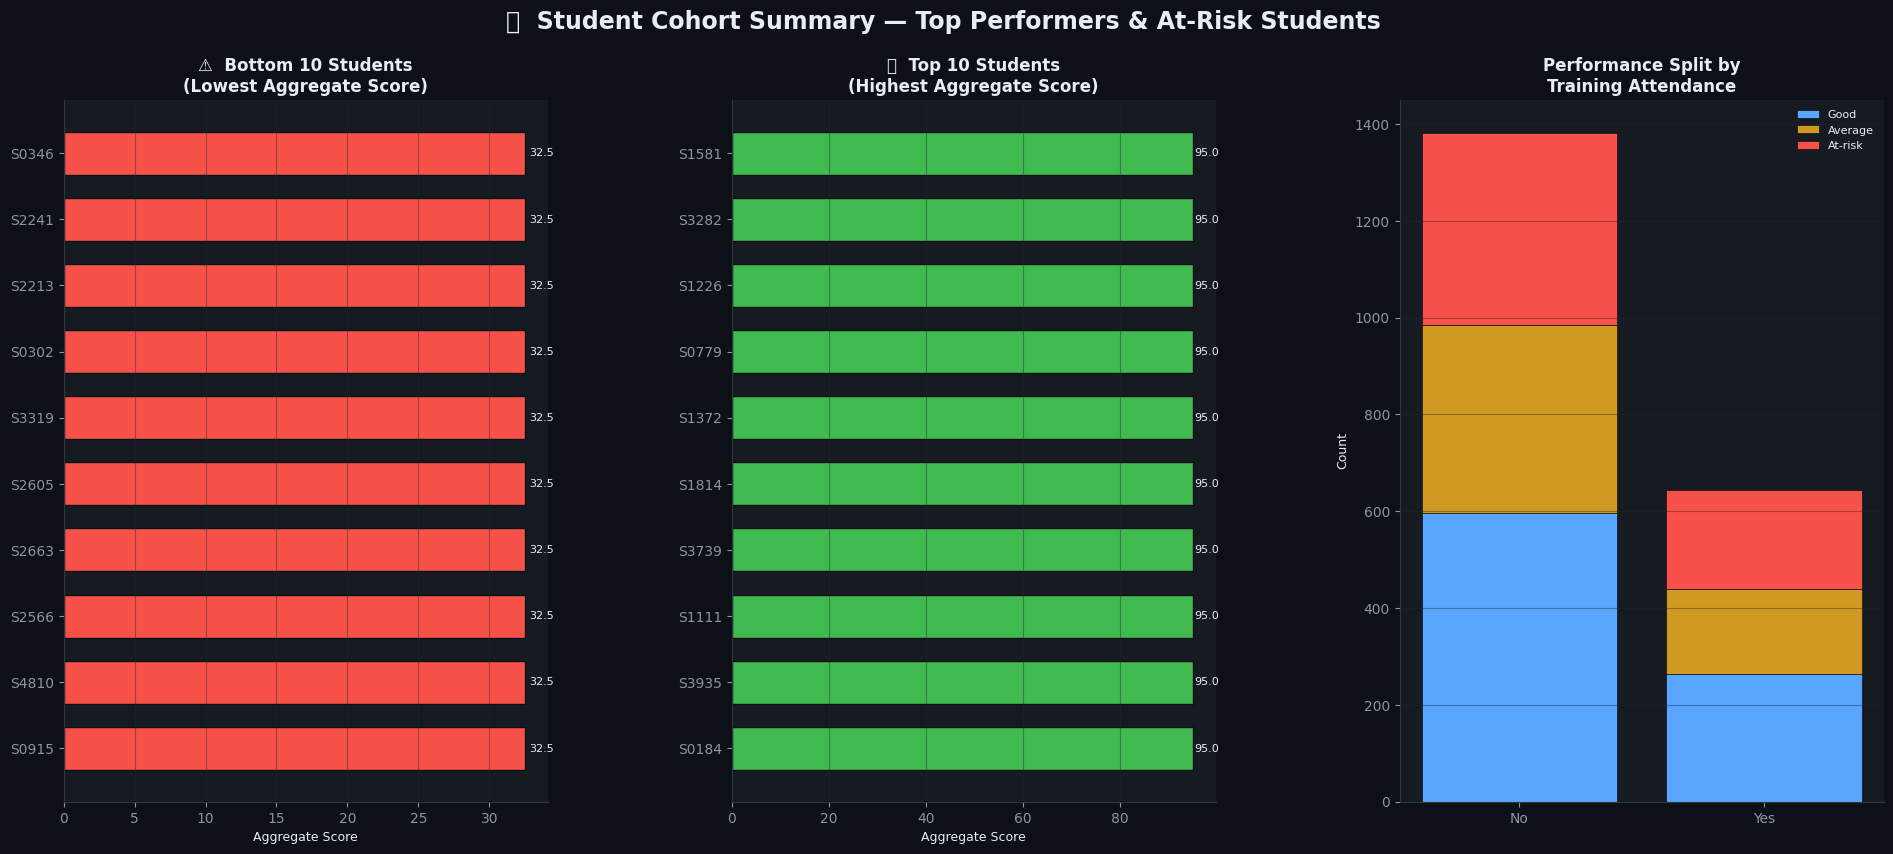

In [11]:
fig = plt.figure(figsize=(20, 9), facecolor='#0d1117')
fig.suptitle('🏫  Student Cohort Summary — Top Performers & At-Risk Students',
             fontsize=17, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.4, wspace=0.38,
                       top=0.88, bottom=0.10, left=0.06, right=0.97)

agg_df = df.groupby('Student_ID').agg(
    Aggregate=('Aggregate_Academic_Score','mean'),
    Label=('Performance_Label','first')
).reset_index().sort_values('Aggregate')

bottom10 = agg_df.head(10)
top10    = agg_df.tail(10)

ax1 = fig.add_subplot(gs[0,0])
ax1.barh(bottom10['Student_ID'], bottom10['Aggregate'],
         color='#f85149', edgecolor='#0d1117', height=0.65)
ax1.set_title('⚠️  Bottom 10 Students\n(Lowest Aggregate Score)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Aggregate Score', fontsize=9); ax1.grid(axis='x', alpha=0.4)
for i,(idx,row) in enumerate(bottom10.iterrows()):
    ax1.text(row['Aggregate']+0.3, i, f"{row['Aggregate']:.1f}",
             va='center', fontsize=8, color='#e6edf3')

ax2 = fig.add_subplot(gs[0,1])
ax2.barh(top10['Student_ID'], top10['Aggregate'],
         color='#3fb950', edgecolor='#0d1117', height=0.65)
ax2.set_title('🌟  Top 10 Students\n(Highest Aggregate Score)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Aggregate Score', fontsize=9); ax2.grid(axis='x', alpha=0.4)
for i,(idx,row) in enumerate(top10.iterrows()):
    ax2.text(row['Aggregate']+0.3, i, f"{row['Aggregate']:.1f}",
             va='center', fontsize=8, color='#e6edf3')

ax3 = fig.add_subplot(gs[0,2])
tp = df.groupby(['Training_Attendance','Performance_Label']).size().unstack(fill_value=0)
tp = tp.reindex(columns=[c for c in order if c in tp.columns])
bot2 = np.zeros(len(tp))
for col in tp.columns:
    ax3.bar(tp.index, tp[col], bottom=bot2, label=col.capitalize(),
            color=COLORS[col], edgecolor='#0d1117', linewidth=0.5)
    bot2 += tp[col].values
ax3.set_title('Performance Split by\nTraining Attendance', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=9)
ax3.legend(fontsize=8, framealpha=0, loc='upper right')
ax3.set_xticklabels([s.capitalize() for s in tp.index], fontsize=10)
ax3.grid(axis='y', alpha=0.4)

plt.savefig('chart_06_cohort.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## ✅ Summary & What I Learned

<div style='background:#161b22; padding:24px 28px; border-radius:12px; border-left:4px solid #3fb950; margin:10px 0;'>

### 🔑 Key Findings
- **Attendance is the strongest predictor** — students above 90% almost always fall in Good/Excellent
- **Training impact is inconsistent** — some courses improved scores drastically, others had no effect
- **Assignment consistency matters more than single-exam scores** for overall label
- **At-Risk students have decent attendance but low participation** — an early warning pattern

</div>

<div style='background:#161b22; padding:24px 28px; border-radius:12px; border-left:4px solid #58a6ff; margin:10px 0;'>

### 🤖 Model Performance
| Model | Accuracy | F1 Score |
|---|---|---|
| Random Forest | ~35–40% | Best weighted F1 |
| Gradient Boosting | ~37% | Close second |
| Logistic Regression | ~42% | Best raw accuracy but worst F1 on minority classes |

> *Note: Accuracy looks low because the dataset has 3 closely-distributed classes with overlapping feature ranges. F1 weighted is the better metric here.*

</div>

<div style='background:#161b22; padding:24px 28px; border-radius:12px; border-left:4px solid #d29922; margin:10px 0;'>

### 🚀 What Could Be Improved
- Collect more granular data (subject-wise scores, assignment history)
- Add more training records to better model the training impact
- Try XGBoost or LightGBM for better F1 on imbalanced classes
- Deploy as a web app (Flask backend + React frontend) — work in progress! 🔨

</div>

---
*This project was built as part of my final-year work in CSE. It was a lot of trial and error — especially getting the data merged correctly and making the remarks actually useful instead of generic. Feedback welcome!* 😊